# Hierarchical Insect Classifier — Baseline (v15 CSV)

## CSV facts (hierarchical_labels_v15.csv)
| Property | Value |
|---|---|
| Total samples | 37,588 (train 28,466 / val 7,120 / test 2,002) |
| Species present | 1-3, 5-12, 14-18, 21-31 (no sp4, sp13, sp19 — already excluded) |
| l1_pest | 0=non-pest (sp21 only), 1=pest |
| l2_role | 0=predator, 1=non-predator, -1=masked |
| l3_pred_type | 0=ladybug-pred, 1=other-pred, -1=masked |
| l3_nonpred_type | 0=ladybug-nonpred, 1=other-nonpred, -1=masked |
| sp_pred_ladybug_common | 0-10 → sp1-3,5-12 (11 classes), -1=masked |
| sp_other_pred | 0-2 → sp14-16 (3 classes), -1=masked |
| sp_nonpred_ladybug | 0-1 → sp17-18 (2 classes), -1=masked |

## Hierarchy
```
level1 (pest/non-pest)
├── 0 → sp21 (non-pest, terminal)
└── 1 → level2 (predator role)
    ├── 0 (predator) → l3a (pred type)
    │   ├── 0 (ladybug-pred) → l4a: 11 classes → sp1,2,3,5,6,7,8,9,10,11,12
    │   └── 1 (other-pred)   → l4b:  3 classes → sp14,15,16
    └── 1 (non-predator) → l3b (nonpred type)
        ├── 0 (ladybug-nonpred) → l4c: 2 classes → sp17,18
        └── 1 (other-nonpred)   → sp22-31 (terminal, merged as sp22)
```

## Changes from old baseline
- Removed `EXCLUDED_SPECIES` filter — v15 CSV is already clean
- Dataset column `sp_pred_ladybug_all` → correct column `sp_pred_ladybug_common`
- `head_l4a` 12 classes → **11 classes** (matches sp_pred_ladybug_common range 0-10)
- `predict_species_id` class-offset table updated to match v15 mapping
- CSV path updated to v15

In [1]:
!pip install timm scikit-learn pandas pillow tqdm -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


## 1. Dataset

In [7]:
# Cell 2 — Dataset
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms


class HierarchicalInsectDataset(Dataset):
    EXCLUDED_SPECIES = {4, 13, 19}

    def __init__(self, csv_file, split, img_size=224):
        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df["split"] == split].reset_index(drop=True)
        self.df = self.df[~self.df["species_id"].isin(self.EXCLUDED_SPECIES)].reset_index(drop=True)
        self.split = split

        # No augmentation — identical transform for all splits
        self.transform = transforms.Compose([
            transforms.Resize(int(img_size * 256 / 224)),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        labels = {
            "level1":     torch.tensor(row["l1_pest"],                 dtype=torch.long),
            "level2":     torch.tensor(row["l2_role"],                 dtype=torch.long),
            "l3a":        torch.tensor(row["l3_pred_type"],            dtype=torch.long),
            "l3b":        torch.tensor(row["l3_nonpred_type"],         dtype=torch.long),
            "l4a":        torch.tensor(row["sp_pred_ladybug_common"],  dtype=torch.long),
            "l4b":        torch.tensor(row["sp_other_pred"],           dtype=torch.long),
            "l4c":        torch.tensor(row["sp_nonpred_ladybug"],      dtype=torch.long),
            "species_id": torch.tensor(row["species_id"],              dtype=torch.long),
        }
        return img, labels

## 2. Model

In [8]:
# Cell 3 — Model
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


class StableAdapter(nn.Module):
    def __init__(self, dim, bottleneck=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, bottleneck),
            nn.LayerNorm(bottleneck),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(bottleneck, dim),
            nn.Dropout(dropout),
        )
        self.gate = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        return x + self.gate * self.net(x)


class EfficientNetHierarchicalV5(nn.Module):
    def __init__(self, backbone="efficientnet_b0", pretrained=True, feat_dim=512):
        super().__init__()

        self.backbone = timm.create_model(
            backbone,
            pretrained=pretrained,
            num_classes=0,
            drop_rate=0.2,
            drop_path_rate=0.3,
        )
        in_features = self.backbone.num_features  # 1280 for B0

        self.shared = nn.Sequential(
            nn.Linear(in_features, feat_dim),
            nn.LayerNorm(feat_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )
        for layer in self.shared:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

        self.adapt_l1  = StableAdapter(feat_dim)
        self.adapt_l2  = StableAdapter(feat_dim)
        self.adapt_l3a = StableAdapter(feat_dim)
        self.adapt_l3b = StableAdapter(feat_dim)
        self.adapt_l4b = StableAdapter(feat_dim)
        self.adapt_l4c = StableAdapter(feat_dim)
        self.adapt_l4a = StableAdapter(feat_dim, bottleneck=128, dropout=0.4)

        self.head_level1 = nn.Linear(feat_dim, 2)
        self.head_level2 = nn.Linear(feat_dim, 2)
        self.head_l3a    = nn.Linear(feat_dim, 2)
        self.head_l3b    = nn.Linear(feat_dim, 2)
        self.head_l4a    = nn.Linear(feat_dim, 12)
        self.head_l4b    = nn.Linear(feat_dim, 3)
        self.head_l4c    = nn.Linear(feat_dim, 2)

        for head in [self.head_level1, self.head_level2, self.head_l3a,
                     self.head_l3b, self.head_l4a, self.head_l4b, self.head_l4c]:
            nn.init.xavier_normal_(head.weight)
            nn.init.zeros_(head.bias)

    def forward(self, x, targets=None):
        feats = self.shared(self.backbone(x))
        outputs = {}
        outputs["level1"] = self.head_level1(self.adapt_l1(feats))
        outputs["level2"] = self.head_level2(self.adapt_l2(feats))
        outputs["l3a"]    = self.head_l3a(self.adapt_l3a(feats))
        outputs["l3b"]    = self.head_l3b(self.adapt_l3b(feats))
        outputs["l4a"]    = self.head_l4a(self.adapt_l4a(feats))
        outputs["l4b"]    = self.head_l4b(self.adapt_l4b(feats))
        outputs["l4c"]    = self.head_l4c(self.adapt_l4c(feats))
        return outputs

## 3. Loss

In [9]:
# Cell 4 — Loss (unchanged from v16)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


class LeafBranchFocalLoss(nn.Module):
    def __init__(self, num_classes=12, alpha=0.25, gamma=4.0, ignore_index=-1):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index
        self.eps = 1e-8

    def forward(self, logits, targets):
        valid = targets != self.ignore_index
        if valid.sum() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        logits = logits[valid]
        targets = targets[valid]
        targets_one_hot = F.one_hot(targets, num_classes=self.num_classes).float()
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.clamp(torch.exp(log_probs), min=self.eps, max=1.0 - self.eps)
        ce_loss = -targets_one_hot * log_probs
        p_t = torch.clamp((probs * targets_one_hot).sum(dim=1), min=self.eps, max=1.0 - self.eps)
        focal_weight = (1 - p_t) ** self.gamma
        return (self.alpha * focal_weight * ce_loss.sum(dim=1)).mean()


class LeafSiblingConsistencyLoss(nn.Module):
    def __init__(self, weight=0.05, similarity_threshold=0.7):
        super().__init__()
        self.weight = weight
        self.similarity_threshold = similarity_threshold

    def forward(self, leaf_logits, sibling_mask=None):
        probs = F.softmax(leaf_logits, dim=1)
        if sibling_mask is None:
            entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)
            return self.weight * entropy.mean()
        batch_size = probs.size(0)
        probs_expanded1 = probs.unsqueeze(2)
        probs_expanded2 = probs.unsqueeze(1)
        diff = torch.abs(probs_expanded1 - probs_expanded2)
        sibling_mask = sibling_mask.unsqueeze(0).expand(batch_size, -1, -1)
        sibling_diff = diff * sibling_mask
        loss = F.relu(sibling_diff - self.similarity_threshold).mean()
        return self.weight * loss


class StableClassBalancedFocalLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.999, gamma_minor=2.0,
                 gamma_major=0.5, ignore_index=-1):
        super().__init__()
        samples_per_class = torch.tensor(samples_per_class, dtype=torch.float)
        effective_num = 1.0 - torch.pow(beta, samples_per_class)
        effective_num = torch.clamp(effective_num, min=1e-8)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.sum()
        self.register_buffer("alpha", weights)
        self.gamma_minor = gamma_minor
        self.gamma_major = gamma_major
        self.ignore_index = ignore_index
        self.eps = 1e-8

    def forward(self, logits, targets):
        valid = targets != self.ignore_index
        if valid.sum() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        logits = logits[valid]
        targets = targets[valid]
        log_probs = F.log_softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(1)).float()
        pt = torch.clamp((torch.exp(log_probs) * targets_one_hot).sum(dim=1),
                         min=self.eps, max=1.0 - self.eps)
        gamma = torch.where(targets == 1,
                            torch.full_like(pt, self.gamma_minor),
                            torch.full_like(pt, self.gamma_major))
        alpha = self.alpha.to(targets.device)[targets]
        return (-alpha * (1.0 - pt) ** gamma * torch.log(pt)).mean()


class CardinalityWeightedCELoss(nn.Module):
    def __init__(self, num_classes, ignore_index=-1, label_smoothing=0.1):
        super().__init__()
        self.scale = 1.0 / (num_classes ** 0.5)
        self.ce = nn.CrossEntropyLoss(ignore_index=ignore_index,
                                      label_smoothing=label_smoothing)

    def forward(self, logits, targets):
        return self.scale * self.ce(logits, targets)


class HierarchicalCoherenceLoss(nn.Module):
    def __init__(self, weight=0.1, ignore_index=-1):
        super().__init__()
        self.weight = weight
        self.ignore_index = ignore_index
        self.eps = 1e-8

    def forward(self, child_logits, parent_logits, child_targets, parent_targets):
        valid = (child_targets != self.ignore_index) & (parent_targets != self.ignore_index)
        if valid.sum() == 0:
            return torch.tensor(0.0, device=child_logits.device, requires_grad=True)
        child_logits  = torch.clamp(child_logits[valid],  min=-10.0, max=10.0)
        parent_logits = torch.clamp(parent_logits[valid], min=-10.0, max=10.0)
        child_prob  = torch.clamp(F.softmax(child_logits,  dim=1).max(dim=1)[0],
                                  min=self.eps, max=1.0 - self.eps)
        parent_prob = torch.clamp(F.softmax(parent_logits, dim=1).max(dim=1)[0],
                                  min=self.eps, max=1.0 - self.eps)
        violation = F.relu(child_prob - parent_prob)
        return self.weight * (violation ** 2).mean()


class HierarchicalMultiTaskLoss(nn.Module):
    def __init__(self, level1_samples, lambda_coherence=0.1,
                 leaf_lambda=0.3, use_leaf_consistency=True):
        super().__init__()

        self.loss_level1    = StableClassBalancedFocalLoss(level1_samples)
        self.loss_level2    = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l3a       = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l3b       = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l4a_ce    = CardinalityWeightedCELoss(12, label_smoothing=0.1)
        self.loss_l4a_focal = LeafBranchFocalLoss(num_classes=12, alpha=0.25, gamma=4.0)
        self.loss_l4b       = CardinalityWeightedCELoss(3,  label_smoothing=0.1)
        self.loss_l4c       = CardinalityWeightedCELoss(2,  label_smoothing=0.1)

        self.use_leaf_consistency = use_leaf_consistency
        if use_leaf_consistency:
            self.leaf_consistency = LeafSiblingConsistencyLoss(weight=0.05)

        self.coherence = HierarchicalCoherenceLoss(weight=lambda_coherence)

        self.task_weights = {
            "level1":    1.0,
            "level2":    0.8,
            "l3a":       0.6,
            "l3b":       0.6,
            "l4a_ce":    0.6,
            "l4a_focal": 0.4,
            "l4b":       0.4,
            "l4c":       0.4,
        }
        self.leaf_lambda = leaf_lambda

    def forward(self, outputs, targets, sibling_mask=None):
        device = next(iter(outputs.values())).device
        total_loss = torch.tensor(0.0, device=device, requires_grad=True)
        loss_components = {}

        l1_loss = self.loss_level1(outputs["level1"], targets["level1"])
        if torch.isfinite(l1_loss):
            total_loss = total_loss + self.task_weights["level1"] * l1_loss
            loss_components["l1"] = l1_loss.item()

        non_pest = targets["level1"] == 0

        def gate(t):
            t = t.clone()
            t[non_pest] = -1
            return t

        t2  = gate(targets["level2"])
        t3a = gate(targets["l3a"])
        t3b = gate(targets["l3b"])
        t4a = gate(targets["l4a"])
        t4b = gate(targets["l4b"])
        t4c = gate(targets["l4c"])

        losses = [
            ("level2",    self.loss_level2(outputs["level2"], t2)),
            ("l3a",       self.loss_l3a(outputs["l3a"], t3a)),
            ("l3b",       self.loss_l3b(outputs["l3b"], t3b)),
            ("l4a_ce",    self.loss_l4a_ce(outputs["l4a"], t4a)),
            ("l4a_focal", self.loss_l4a_focal(outputs["l4a"], t4a)),
            ("l4b",       self.loss_l4b(outputs["l4b"], t4b)),
            ("l4c",       self.loss_l4c(outputs["l4c"], t4c)),
        ]

        for task_name, loss_val in losses:
            if torch.isfinite(loss_val):
                total_loss = total_loss + self.task_weights[task_name] * loss_val
                loss_components[task_name] = loss_val.item()

        if self.use_leaf_consistency and "l4a" in outputs:
            lc = self.leaf_consistency(outputs["l4a"], sibling_mask)
            if torch.isfinite(lc):
                total_loss = total_loss + lc
                loss_components["leaf_consistency"] = lc.item()

        coherence_losses = [
            ("coh_l3a_level2", self.coherence(outputs["l3a"], outputs["level2"], t3a, t2)),
            ("coh_l3b_level2", self.coherence(outputs["l3b"], outputs["level2"], t3b, t2)),
            ("coh_l4a_l3a",   self.coherence(outputs["l4a"], outputs["l3a"],    t4a, t3a)),
            ("coh_l4c_l3b",   self.coherence(outputs["l4c"], outputs["l3b"],    t4c, t3b)),
        ]
        for coh_name, coh_loss in coherence_losses:
            if torch.isfinite(coh_loss):
                total_loss = total_loss + coh_loss
                loss_components[coh_name] = coh_loss.item()

        if not torch.isfinite(total_loss):
            return torch.tensor(0.0, device=device, requires_grad=True), loss_components

        return total_loss, loss_components

    def get_leaf_accuracy_weights(self, current_epoch, total_epochs):
        progress = current_epoch / total_epochs
        if progress < 0.3:
            self.task_weights["l4a_ce"] = 0.7
            self.task_weights["l4a_focal"] = 0.1
        elif progress < 0.7:
            self.task_weights["l4a_ce"] = 0.6
            self.task_weights["l4a_focal"] = 0.3
        else:
            self.task_weights["l4a_ce"] = 0.4
            self.task_weights["l4a_focal"] = 0.5


def create_ladybug_sibling_mask():
    num_classes = 12
    mask = torch.zeros(num_classes, num_classes)
    groups = [[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10], [11]]
    for group in groups:
        for i in group:
            for j in group:
                if i != j:
                    mask[i, j] = 1.0
    return mask

## 4. Helper: decode outputs → species_id

Mapping derived directly from v15 CSV:

| Head | Class | Species ID |
|---|---|---|
| level1==0 | — | 21 |
| l4a | 0 | 1 |
| l4a | 1 | 2 |
| l4a | 2 | 3 |
| l4a | 3 | 5 |
| l4a | 4 | 6 |
| l4a | 5 | 7 |
| l4a | 6 | 8 |
| l4a | 7 | 9 |
| l4a | 8 | 10 |
| l4a | 9 | 11 |
| l4a | 10 | 12 |
| l4b | 0 | 14 |
| l4b | 1 | 15 |
| l4b | 2 | 16 |
| l4c | 0 | 17 |
| l4c | 1 | 18 |
| level2==1 + l3b==1 | — | 22 (merged 22-31) |

## 5. Training

In [10]:
# Cell 5 — Training
import os
import torch
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict
import pandas as pd

# ===================== CONFIG =====================
CSV_PATH     = "/workspace/hierarchical_labels_v15.csv"
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 70
LR           = 1.5e-4
LR_L4A       = LR * 0.5
NUM_WORKERS  = 10
PATIENCE     = 8
WEIGHT_DECAY = 3e-4

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_DIR = "/workspace/model_v17_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

print("🔥 DEVICE:", DEVICE)

# ===================== DATA =====================
df = pd.read_csv(CSV_PATH)

train_ds = HierarchicalInsectDataset(CSV_PATH, split="train", img_size=IMG_SIZE)
val_ds   = HierarchicalInsectDataset(CSV_PATH, split="val",   img_size=IMG_SIZE)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")

all_species_ids = sorted(set(
    22 if 22 <= int(s) <= 31 else int(s)
    for s in df["species_id"].unique()
    if int(s) not in {4, 13, 19}
))

# ===================== MODEL =====================
model = EfficientNetHierarchicalV5(
    backbone="efficientnet_b0", pretrained=True, feat_dim=512
).to(DEVICE)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS =====================
l1_counts = train_ds.df["l1_pest"].value_counts().sort_index().values.tolist()
criterion = HierarchicalMultiTaskLoss(level1_samples=l1_counts, lambda_coherence=0.1)
sibling_mask = create_ladybug_sibling_mask().to(DEVICE)

# ===================== OPTIMIZER =====================
l4a_params    = list(model.adapt_l4a.parameters()) + list(model.head_l4a.parameters())
l4a_param_ids = set(id(p) for p in l4a_params)
other_params  = [p for p in model.parameters() if id(p) not in l4a_param_ids]

optimizer = optim.AdamW(
    [
        {"params": other_params, "lr": LR},
        {"params": l4a_params,   "lr": LR_L4A, "weight_decay": WEIGHT_DECAY * 2},
    ],
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8,
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR, LR_L4A],
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.15,
    anneal_strategy="cos",
)

use_amp = DEVICE == "cuda"
scaler  = torch.amp.GradScaler("cuda", enabled=use_amp) if use_amp else None

# ===================== HELPERS =====================
def predict_species_id(outputs):
    device = outputs["level1"].device
    B = outputs["level1"].shape[0]
    preds = torch.full((B,), fill_value=-1, dtype=torch.long, device=device)
    l1  = outputs["level1"].argmax(1)
    l2  = outputs["level2"].argmax(1)
    l3a = outputs["l3a"].argmax(1)
    l3b = outputs["l3b"].argmax(1)
    l4a = outputs["l4a"].argmax(1)
    l4b = outputs["l4b"].argmax(1)
    l4c = outputs["l4c"].argmax(1)
    preds[l1 == 0] = 21
    m_low  = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a <= 2)
    preds[m_low]  = l4a[m_low] + 1
    m_high = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a >= 3) & (l4a <= 8)
    preds[m_high] = l4a[m_high] + 2
    m_sp11 = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a == 9)
    preds[m_sp11] = 11
    m_sp12 = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a == 10)
    preds[m_sp12] = 12
    m = (l1 == 1) & (l2 == 0) & (l3a == 1)
    preds[m] = l4b[m] + 14
    m = (l1 == 1) & (l2 == 1) & (l3b == 0)
    preds[m] = l4c[m] + 17
    m = (l1 == 1) & (l2 == 1) & (l3b == 1)
    preds[m] = 22
    return preds


def masked_accuracy(logits, targets):
    mask = targets != -1
    if mask.sum() == 0:
        return None
    with torch.no_grad():
        preds = logits.argmax(dim=1)
        return (preds[mask] == targets[mask]).float().mean().item()


def merge_sp(sid):
    return 22 if 22 <= int(sid) <= 31 else int(sid)

# ===================== TRAINING LOOP =====================
best_val_acc     = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}  |  LR: {optimizer.param_groups[0]['lr']:.2e}")
    print(f"{'='*60}")

    criterion.get_leaf_accuracy_weights(epoch, EPOCHS)

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    train_accs = defaultdict(list)
    tr_correct = tr_total = 0

    for images, labels in tqdm(train_loader, desc="TRAIN", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)
            total_loss, loss_components = criterion(outputs, labels, sibling_mask)

        if use_amp:
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()
        train_loss += total_loss.item()

        for head in outputs:
            if head in labels:
                acc = masked_accuracy(outputs[head], labels[head])
                if acc is not None:
                    train_accs[head].append(acc)

        with torch.no_grad():
            sp_pred = predict_species_id(outputs)
            sp_tgt  = labels["species_id"]
            sp_pred_m = torch.tensor([merge_sp(s) for s in sp_pred.cpu().tolist()], device=DEVICE)
            sp_tgt_m  = torch.tensor([merge_sp(s) for s in sp_tgt.cpu().tolist()],  device=DEVICE)
            tr_correct += (sp_pred_m == sp_tgt_m).sum().item()
            tr_total   += sp_tgt.size(0)

    # ---- VALIDATE ----
    model.eval()
    val_loss = 0.0
    val_accs = defaultdict(list)
    va_correct = va_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="VALID", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}

            outputs = model(images)
            total_loss, _ = criterion(outputs, labels, sibling_mask)
            val_loss += total_loss.item()

            for head in outputs:
                if head in labels:
                    acc = masked_accuracy(outputs[head], labels[head])
                    if acc is not None:
                        val_accs[head].append(acc)

            sp_pred = predict_species_id(outputs)
            sp_tgt  = labels["species_id"]
            sp_pred_m = torch.tensor([merge_sp(s) for s in sp_pred.cpu().tolist()], device=DEVICE)
            sp_tgt_m  = torch.tensor([merge_sp(s) for s in sp_tgt.cpu().tolist()],  device=DEVICE)
            va_correct += (sp_pred_m == sp_tgt_m).sum().item()
            va_total   += sp_tgt.size(0)

    # ---- REPORT ----
    avg_tr_loss = train_loss / len(train_loader)
    avg_va_loss = val_loss   / len(val_loader)
    tr_sp_acc   = tr_correct / tr_total if tr_total else 0
    va_sp_acc   = va_correct / va_total if va_total else 0

    print(f"  Train Loss: {avg_tr_loss:.4f}  |  Val Loss: {avg_va_loss:.4f}")
    print(f"  Train Species Acc: {tr_sp_acc:.4f}  |  Val Species Acc: {va_sp_acc:.4f}")
    print(f"  Per-head accuracies (val):")
    for head in sorted(val_accs):
        t = np.mean(train_accs[head]) if train_accs[head] else 0.0
        v = np.mean(val_accs[head])   if val_accs[head]   else 0.0
        print(f"    {head:<10} | train {t:.4f}  val {v:.4f}  gap {t-v:+.4f}")

    # ---- CHECKPOINT ----
    if va_sp_acc > best_val_acc:
        best_val_acc     = va_sp_acc
        patience_counter = 0
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "val_species_acc":  va_sp_acc,
            "val_loss":         avg_va_loss,
        }, os.path.join(SAVE_DIR, "best_model.pth"))
        print(f"  ✅ Saved best model (val species acc: {va_sp_acc:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("\n🛑 Early stopping triggered.")
            break

print(f"\n🏆 Done. Best val species accuracy: {best_val_acc:.4f}")

🔥 DEVICE: cuda
Train: 28,466 | Val: 7,120
Trainable params: 5,206,684

Epoch 1/70  |  LR: 6.00e-06


TRAIN:   0%|          | 0/889 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:216: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  Train Loss: 2.0424  |  Val Loss: 0.7861
  Train Species Acc: 0.1354  |  Val Species Acc: 0.3348
  Per-head accuracies (val):
    l3a        | train 0.6752  val 0.8581  gap -0.1829
    l3b        | train 0.7112  val 0.8766  gap -0.1653
    l4a        | train 0.1054  val 0.2372  gap -0.1318
    l4b        | train 0.5453  val 0.7853  gap -0.2400
    l4c        | train 0.6349  val 0.7967  gap -0.1618
    level1     | train 0.8349  val 0.9644  gap -0.1295
    level2     | train 0.7164  val 0.8020  gap -0.0855
  ✅ Saved best model (val species acc: 0.3348)

Epoch 2/70  |  LR: 9.20e-06


  Train Loss: 1.4633  |  Val Loss: 0.5917
  Train Species Acc: 0.3507  |  Val Species Acc: 0.6008
  Per-head accuracies (val):
    l3a        | train 0.8464  val 0.9267  gap -0.0803
    l3b        | train 0.8674  val 0.9483  gap -0.0809
    l4a        | train 0.2718  val 0.5293  gap -0.2575
    l4b        | train 0.7660  val 0.9040  gap -0.1380
    l4c        | train 0.8255  val 0.8871  gap -0.0617
    level1     | train 0.9574  val 0.9842  gap -0.0268
    level2     | train 0.8052  val 0.8786  gap -0.0733
  ✅ Saved best model (val species acc: 0.6008)

Epoch 3/70  |  LR: 1.85e-05


  Train Loss: 1.1487  |  Val Loss: 0.4928
  Train Species Acc: 0.5506  |  Val Species Acc: 0.7260
  Per-head accuracies (val):
    l3a        | train 0.9036  val 0.9525  gap -0.0489
    l3b        | train 0.9318  val 0.9719  gap -0.0401
    l4a        | train 0.5003  val 0.6907  gap -0.1904
    l4b        | train 0.8737  val 0.9383  gap -0.0645
    l4c        | train 0.8935  val 0.9412  gap -0.0477
    level1     | train 0.9786  val 0.9886  gap -0.0101
    level2     | train 0.8645  val 0.9141  gap -0.0495
  ✅ Saved best model (val species acc: 0.7260)

Epoch 4/70  |  LR: 3.31e-05


...

  Train Loss: 0.4622  |  Val Loss: 0.3200
  Train Species Acc: 0.9991  |  Val Species Acc: 0.9254
  Per-head accuracies (val):
    l3a        | train 1.0000  val 0.9918  gap +0.0082
    l3b        | train 1.0000  val 0.9935  gap +0.0065
    l4a        | train 0.9992  val 0.9158  gap +0.0834
    l4b        | train 0.9997  val 0.9761  gap +0.0236
    l4c        | train 1.0000  val 0.9853  gap +0.0147
    level1     | train 1.0000  val 0.9986  gap +0.0014
    level2     | train 0.9996  val 0.9742  gap +0.0254
  ⏳ No improvement (4/8)

Epoch 59/70  |  LR: 1.46e-05


  Train Loss: 0.4621  |  Val Loss: 0.3195
  Train Species Acc: 0.9992  |  Val Species Acc: 0.9265
  Per-head accuracies (val):
    l3a        | train 0.9999  val 0.9914  gap +0.0085
    l3b        | train 1.0000  val 0.9941  gap +0.0059
    l4a        | train 0.9993  val 0.9148  gap +0.0844
    l4b        | train 0.9999  val 0.9742  gap +0.0257
    l4c        | train 0.9993  val 0.9853  gap +0.0140
    level1     | train 1.0000  val 0.9987  gap +0.0012
    level2     | train 0.9998  val 0.9757  gap +0.0242
  ⏳ No improvement (5/8)

Epoch 60/70  |  LR: 1.23e-05


  Train Loss: 0.4627  |  Val Loss: 0.3199
  Train Species Acc: 0.9991  |  Val Species Acc: 0.9258
  Per-head accuracies (val):
    l3a        | train 0.9998  val 0.9910  gap +0.0087
    l3b        | train 1.0000  val 0.9941  gap +0.0059
    l4a        | train 0.9996  val 0.9150  gap +0.0846
    l4b        | train 0.9996  val 0.9742  gap +0.0254
    l4c        | train 0.9998  val 0.9794  gap +0.0204
    level1     | train 1.0000  val 0.9985  gap +0.0015
    level2     | train 0.9996  val 0.9750  gap +0.0246
  ⏳ No improvement (6/8)

Epoch 61/70  |  LR: 1.02e-05


  Train Loss: 0.4620  |  Val Loss: 0.3213
  Train Species Acc: 0.9994  |  Val Species Acc: 0.9243
  Per-head accuracies (val):
    l3a        | train 1.0000  val 0.9914  gap +0.0086
    l3b        | train 1.0000  val 0.9941  gap +0.0059
    l4a        | train 0.9995  val 0.9123  gap +0.0872
    l4b        | train 0.9999  val 0.9749  gap +0.0250
    l4c        | train 1.0000  val 0.9853  gap +0.0147
    level1     | train 0.9999  val 0.9989  gap +0.0011
    level2     | train 0.9997  val 0.9744  gap +0.0254
  ⏳ No improvement (7/8)

Epoch 62/70  |  LR: 8.31e-06


  Train Loss: 0.4619  |  Val Loss: 0.3210
  Train Species Acc: 0.9996  |  Val Species Acc: 0.9236
  Per-head accuracies (val):
    l3a        | train 1.0000  val 0.9918  gap +0.0082
    l3b        | train 1.0000  val 0.9948  gap +0.0052
    l4a        | train 0.9997  val 0.9127  gap +0.0870
    l4b        | train 1.0000  val 0.9733  gap +0.0267
    l4c        | train 0.9984  val 0.9853  gap +0.0131
    level1     | train 1.0000  val 0.9987  gap +0.0013
    level2     | train 0.9998  val 0.9741  gap +0.0257
  ⏳ No improvement (8/8)

🛑 Early stopping triggered.

🏆 Done. Best val species accuracy: 0.9270


## 6. Evaluation (Test Split)

Loaded epoch 54  (saved val acc: 0.9270)


TEST: 100%|██████████| 63/63 [00:24<00:00,  2.52it/s]



TEST RESULTS — per species
Species              Acc  Precision   Recall       F1   Correct   Total
--------------------------------------------------------------------------------
sp1               0.8081     0.8511   0.8081   0.8290        80      99
sp2               0.9265     0.8289   0.9265   0.8750        63      68
sp3               0.9589     0.8861   0.9589   0.9211        70      73
sp5               0.8158     0.8493   0.8158   0.8322        62      76
sp6               0.8101     0.7711   0.8101   0.7901        64      79
sp7               0.8816     0.9054   0.8816   0.8933        67      76
sp8               0.8281     0.8154   0.8281   0.8217        53      64
sp9               0.7647     0.8814   0.7647   0.8189        52      68
sp10              0.8615     0.8750   0.8615   0.8682        56      65
sp11              0.8378     0.9118   0.8378   0.8732        62      74
sp12              0.8837     0.7170   0.8837   0.7917        38      43
sp14              0.8824   

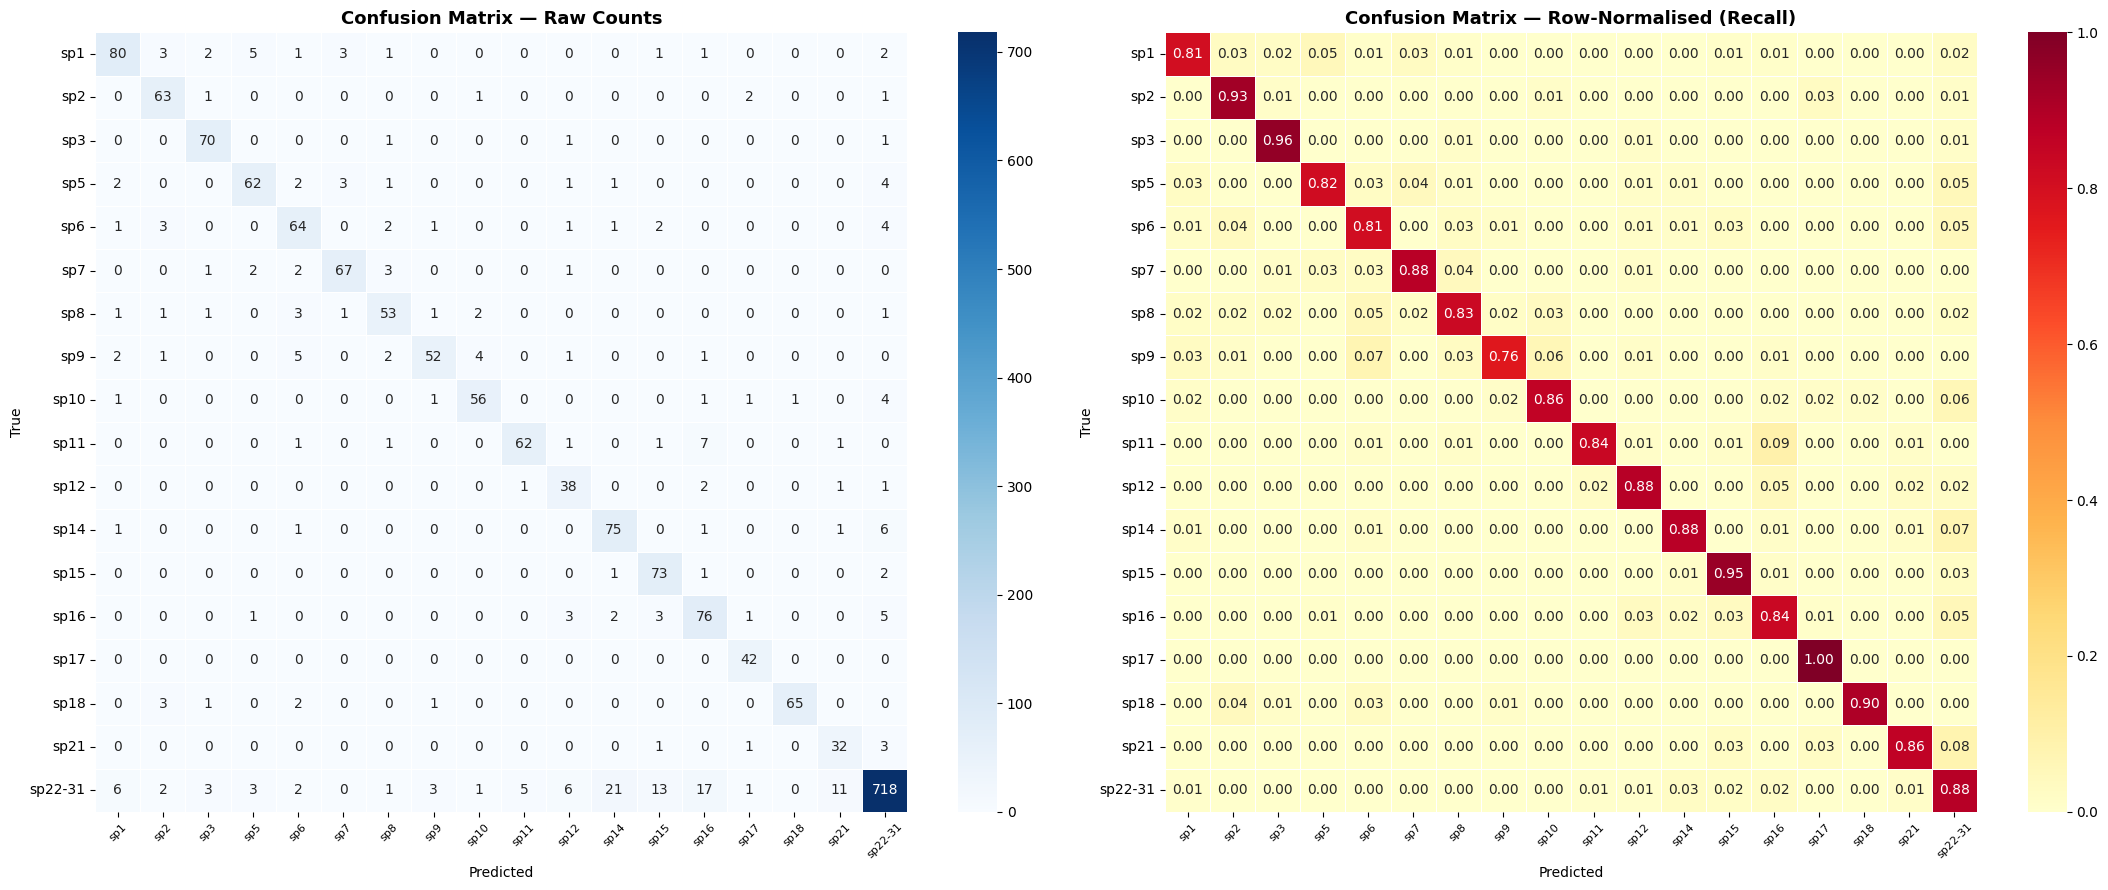

In [12]:
# Cell 6 — Evaluation (Test Split)
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef,
    balanced_accuracy_score,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

CHECKPOINT_PATH = "/workspace/model_v17_checkpoints/best_model.pth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SPECIES_LABEL_MAP = {
    1: "sp1",  2: "sp2",  3: "sp3",  5: "sp5",  6: "sp6",
    7: "sp7",  8: "sp8",  9: "sp9",  10: "sp10", 11: "sp11",
    12: "sp12", 14: "sp14", 15: "sp15", 16: "sp16",
    17: "sp17", 18: "sp18", 21: "sp21", 22: "sp22-31",
}
ALL_SPECIES   = sorted(SPECIES_LABEL_MAP.keys())
SPECIES_NAMES = [SPECIES_LABEL_MAP[s] for s in ALL_SPECIES]

test_ds     = HierarchicalInsectDataset(CSV_PATH, split="test", img_size=IMG_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)

model_eval = EfficientNetHierarchicalV5(
    backbone="efficientnet_b0", pretrained=False, feat_dim=512
).to(DEVICE)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model_eval.load_state_dict(ckpt["model_state_dict"])
model_eval.eval()
print(f"Loaded epoch {ckpt['epoch']}  (saved val acc: {ckpt['val_species_acc']:.4f})")

all_preds   = []
all_targets = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="TEST"):
        images = images.to(DEVICE, non_blocking=True)
        labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}
        outputs  = model_eval(images)
        sp_pred  = predict_species_id(outputs).cpu().numpy()
        sp_tgt   = labels["species_id"].cpu().numpy()
        for pred, tgt in zip(sp_pred, sp_tgt):
            all_targets.append(merge_sp(tgt))
            all_preds.append(merge_sp(pred) if pred != -1 else -1)

all_targets = np.array(all_targets)
all_preds   = np.array(all_preds)

# Per-species table
print(f"\n{'='*80}\nTEST RESULTS — per species\n{'='*80}")
print(f"{'Species':<16} {'Acc':>7} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Correct':>9} {'Total':>7}")
print(f"{'-'*80}")

total_correct = total_samples = 0
per_species_acc = {}

for sid in ALL_SPECIES:
    mask  = all_targets == sid
    total = mask.sum()
    if total == 0:
        continue
    correct = (all_preds[mask] == sid).sum()
    acc     = correct / total
    y_true_bin = (all_targets == sid).astype(int)
    y_pred_bin = (all_preds   == sid).astype(int)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec  = recall_score(y_true_bin,    y_pred_bin, zero_division=0)
    f1   = f1_score(y_true_bin,        y_pred_bin, zero_division=0)
    flag = " ⚠️" if acc < 0.70 else ""
    print(f"{SPECIES_LABEL_MAP[sid]:<16} {acc:>7.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {correct:>9} {total:>7}{flag}")
    per_species_acc[sid] = acc
    total_correct += correct
    total_samples += total

overall_acc = total_correct / total_samples if total_samples else 0.0
print(f"{'-'*80}\n{'OVERALL':<16} {overall_acc:>7.4f}")

# Aggregate metrics
valid = all_preds != -1
y_true, y_pred = all_targets[valid], all_preds[valid]
labels_present = [s for s in ALL_SPECIES if s in y_true]

print(f"\n{'='*80}\nAGGREGATE METRICS\n{'='*80}")
print(f"  Overall Accuracy   : {overall_acc:.4f}")
print(f"  Balanced Accuracy  : {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"  Macro F1           : {f1_score(y_true, y_pred, labels=labels_present, average='macro', zero_division=0):.4f}")
print(f"  Weighted F1        : {f1_score(y_true, y_pred, labels=labels_present, average='weighted', zero_division=0):.4f}")
print(f"  Cohen Kappa        : {cohen_kappa_score(y_true, y_pred):.4f}")
print(f"  MCC                : {matthews_corrcoef(y_true, y_pred):.4f}")

# Confusion matrix
cm      = confusion_matrix(y_true, y_pred, labels=labels_present)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
target_names = [SPECIES_LABEL_MAP[s] for s in labels_present]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
sns.heatmap(cm,      ax=axes[0], xticklabels=target_names, yticklabels=target_names,
            annot=True, fmt="d",    cmap="Blues",   linewidths=0.4)
sns.heatmap(cm_norm, ax=axes[1], xticklabels=target_names, yticklabels=target_names,
            annot=True, fmt=".2f",  cmap="YlOrRd",  vmin=0, vmax=1, linewidths=0.4)
axes[0].set_title("Confusion Matrix — Raw Counts",           fontsize=13, fontweight="bold")
axes[1].set_title("Confusion Matrix — Row-Normalised (Recall)", fontsize=13, fontweight="bold")
for ax in axes:
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig("/workspace/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()